In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

In [3]:
path = "data/bank-full.csv"
df = pd.read_csv(path,delimiter=';')

In [4]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
columns = ['y','day','month']
X = df.drop(columns=columns)
X = pd.get_dummies(X)
y = df['y']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y)

In [8]:
gini_tree = DecisionTreeClassifier(random_state=42,criterion='gini')
gini_tree.fit(X_train,y_train)
ig_tree = DecisionTreeClassifier(random_state=42,criterion='entropy')
ig_tree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [9]:
y_pred_gini = gini_tree.predict(X_test)
y_pred_ig = ig_tree.predict(X_test)

In [10]:
cm1 = metrics.confusion_matrix(y_test,y_pred_gini)

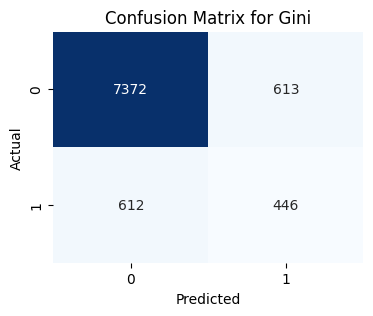

In [11]:
plt.figure(figsize=(4,3))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix for Gini")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
cm2 = metrics.confusion_matrix(y_test,y_pred_ig)

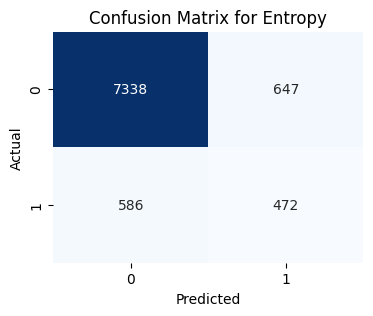

In [13]:
plt.figure(figsize=(4,3))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix for Entropy")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()